--- Starting Phase 1, Final Stage: Training the XGBoost Model ---
Successfully loaded the feature matrix with 1075 grid cells.

Features for the model: ['vs_mean', 'vs_std', 'strain_azimuth']
Target variable: earthquake_occurred

Data split into 860 training samples and 215 testing samples.

Training the XGBoost model...


/home/sat/Code/Fun/earthquake_proj/.venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [04:03:04] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


...Training complete.

--- Model Performance Evaluation ---
Accuracy on test set: 0.8512

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.88      0.90       167
           1       0.64      0.75      0.69        48

    accuracy                           0.85       215
   macro avg       0.78      0.82      0.80       215
weighted avg       0.86      0.85      0.86       215


Confusion Matrix:
[[147  20]
 [ 12  36]]


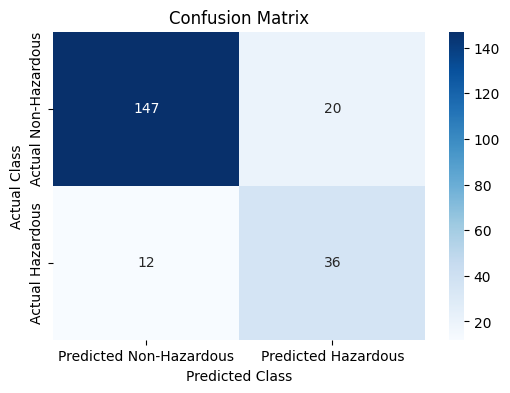


--- Generating Final Susceptibility Map ---
Predicted earthquake susceptibility for all grid cells.

Successfully saved final results to: susceptibility_map_results.csv

First 5 rows of the final output:
   longitude  latitude  susceptibility  earthquake_occurred
0       49.9      34.4        0.001903                    0
1       50.0      34.4        0.001903                    0
2       50.1      34.4        0.001903                    0
3       50.2      34.4        0.001903                    0
4       50.3      34.4        0.001903                    0

--- Phase 1 Complete! ---


In [1]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import os


def train_susceptibility_model(feature_matrix_filepath, output_filepath):
    """
    Trains an XGBoost classifier to predict earthquake susceptibility.

    This function loads the final feature matrix, splits it into training and
    testing sets, trains an XGBoost model, evaluates its performance, and then
    uses the trained model to predict the susceptibility for the entire grid.
    The final grid with predictions is saved to a new CSV.

    Args:
        feature_matrix_filepath (str): Path to the final feature matrix CSV.
        output_filepath (str): Path to save the grid with susceptibility predictions.
    """
    print("--- Starting Phase 1, Final Stage: Training the XGBoost Model ---")

    # --- 1. Load the dataset ---
    try:
        df = pd.read_csv(feature_matrix_filepath)
        print(f"Successfully loaded the feature matrix with {len(df)} grid cells.")
    except FileNotFoundError:
        print(f"Error: The feature matrix '{feature_matrix_filepath}' was not found.")
        return

    # --- 2. Define Features (X) and Target (y) ---
    # The features are all columns except for the lat/lon and the target variable.
    features = ["vs_mean", "vs_std", "strain_azimuth"]
    target = "earthquake_occurred"

    X = df[features]
    y = df[target]
    print("\nFeatures for the model:", features)
    print("Target variable:", target)

    # --- 3. Split data into training and testing sets ---
    # We'll use 80% of the data to train the model and 20% to test its performance.
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    print(
        f"\nData split into {len(X_train)} training samples and {len(X_test)} testing samples."
    )

    # --- 4. Initialize and Train the XGBoost Classifier ---
    print("\nTraining the XGBoost model...")
    # The scale_pos_weight parameter is important for imbalanced datasets.
    # It helps the model pay more attention to the minority class (earthquakes).
    scale_pos_weight = (y == 0).sum() / (y == 1).sum()

    model = xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        use_label_encoder=False,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
    )

    model.fit(X_train, y_train)
    print("...Training complete.")

    # --- 5. Evaluate Model Performance on the Test Set ---
    print("\n--- Model Performance Evaluation ---")
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy on test set: {accuracy:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)
    # Optional: Plot the confusion matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Predicted Non-Hazardous", "Predicted Hazardous"],
        yticklabels=["Actual Non-Hazardous", "Actual Hazardous"],
    )
    plt.title("Confusion Matrix")
    plt.ylabel("Actual Class")
    plt.xlabel("Predicted Class")
    plt.show()

    # --- 6. Predict Susceptibility for the Entire Grid ---
    print("\n--- Generating Final Susceptibility Map ---")
    # We use predict_proba to get the probability of the positive class (earthquake_occurred=1)
    susceptibility_probabilities = model.predict_proba(X)[:, 1]

    # Add this as a new column to our original dataframe
    df["susceptibility"] = susceptibility_probabilities
    print("Predicted earthquake susceptibility for all grid cells.")

    # --- 7. Save the Final Results ---
    df.to_csv(output_filepath, index=False)
    print(f"\nSuccessfully saved final results to: {output_filepath}")

    print("\nFirst 5 rows of the final output:")
    print(df[["longitude", "latitude", "susceptibility", "earthquake_occurred"]].head())

    print("\n--- Phase 1 Complete! ---")


# --- Main execution block ---
if __name__ == "__main__":
    # Define the input and output files
    feature_matrix_file = "final_feature_matrix.csv"
    output_file = "susceptibility_map_results.csv"

    # Run the model training function
    train_susceptibility_model(feature_matrix_file, output_file)


--- Starting Visualization ---
Successfully loaded susceptibility results and earthquake catalog.


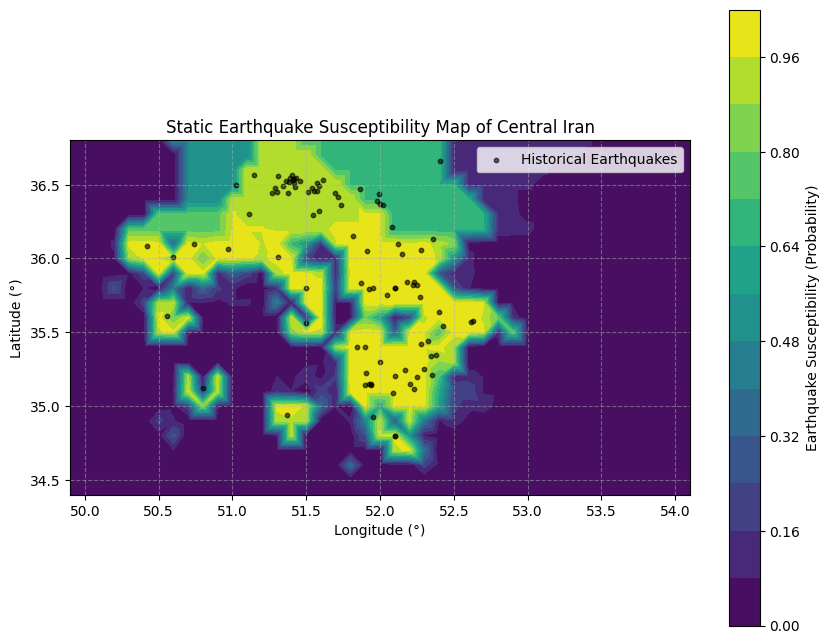


--- Visualization Complete ---
This map is the final output of Phase 1.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.interpolate

def visualize_susceptibility_map(results_filepath, eq_filepath):
    """
    Creates a 2D plot of the earthquake susceptibility map.

    This function loads the final results file containing grid coordinates and
    predicted susceptibilities. It then creates a heatmap visualization of the
    susceptibility values and overlays the locations of historical earthquakes
    for comparison.

    Args:
        results_filepath (str): Path to the susceptibility_map_results.csv file.
        eq_filepath (str): Path to the cleaned earthquake catalog CSV file.
    """
    print("--- Starting Visualization ---")

    # --- 1. Load the results and earthquake data ---
    try:
        df = pd.read_csv(results_filepath)
        eq_df = pd.read_csv(eq_filepath)
        print("Successfully loaded susceptibility results and earthquake catalog.")
    except FileNotFoundError as e:
        print(f"Error: A required data file was not found. {e}")
        return

    # --- 2. Create the plot ---
    fig, ax = plt.subplots(figsize=(10, 8))

    # Use tricontourf for plotting irregularly spaced data, which is robust
    # It creates filled contour plots, which look like a heatmap.
    contour = ax.tricontourf(
        df['longitude'], df['latitude'], df['susceptibility'],
        levels=14, cmap='viridis' # 'viridis', 'plasma', 'inferno', 'magma' are good colormaps
    )

    # Add a color bar to the plot to show what the colors mean
    cbar = fig.colorbar(contour)
    cbar.set_label('Earthquake Susceptibility (Probability)')

    # --- 3. Overlay historical earthquakes ---
    ax.scatter(
        eq_df['long'], eq_df['lat'],
        s=10,         # size of the dots
        c='black',    # color of the dots
        alpha=0.6,    # transparency
        label='Historical Earthquakes'
    )

    # --- 4. Set plot labels and title ---
    ax.set_title('Static Earthquake Susceptibility Map of Central Iran')
    ax.set_xlabel('Longitude (°)')
    ax.set_ylabel('Latitude (°)')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

    # Ensure the aspect ratio is equal to avoid distortion
    ax.set_aspect('equal', adjustable='box')

    # --- 5. Show the plot ---
    plt.show()
    print("\n--- Visualization Complete ---")
    print("This map is the final output of Phase 1.")

# --- Main execution block ---
if __name__ == '__main__':
    # Define the input files
    results_file = 'susceptibility_map_results.csv'
    eq_file = '../assets/data/cleaned_historical_Eq.csv'

    # Run the visualization function
    visualize_susceptibility_map(results_file, eq_file)
